In [1]:
import numpy as np
import pandas as pd
from pid.utils.generate import generate_cov_from_config, random_rotation_mxy, merge_covs
from pid.optimizers import exact_gauss_tilde_pid, exact_gauss_thin_pid, flow_pid

In [2]:
# Starting from 2-D case
dm, dx, dy = 2, 2, 2
theta = 0
gain_y = np.sqrt(2)
gains = np.linspace(0.5, 3, 10)
gains[3] = 0.99  # A gain of 1 is unstable

In [3]:
for i, gain_x in enumerate(gains):
    cov, *dims = generate_cov_from_config(d=(dm, dx, dy), gain=(gain_x, gain_y), theta=theta)
    # Generate random samples from the multivariate Gaussian distribution
    num_samples = 10  # Number of samples to generate
    mean = np.zeros(sum(dims))
    samples = np.random.multivariate_normal(mean, cov, num_samples)
    # print(f'{samples} \n')

In [4]:
# Extend to multi-dimensional case
gains = np.linspace(0, 3, 10)
gains[3] = 0.99  # A gain of 1 is unstable
#gains = np.array([3.0,])
num_doubles = 3
random_rotn = True

# for simplicity, I only print gains[0]
gain = gains[0]
for j in range(num_doubles):
    if j == 0:
        dm, dx, dy = 2, 2, 2
        hx = np.array([[gain, 0], [0, 1]])
        hy = np.array([[1, 0], [0, np.sqrt(2)]])
        sigm = np.eye(dm)
        sigx_m = np.eye(dx)
        sigy_m = np.eye(dy)
        sigw = np.zeros((dx, dy))
        cov = np.block([[sigm, sigm @ hx.T, sigm @ hy.T],
                        [hx @ sigm, hx @ sigm @ hx.T + sigx_m, hx @ sigm @ hy.T + sigw],
                        [hy @ sigm, hy @ sigm @ hx.T + sigw.T, hy @ sigm @ hy.T + sigy_m]])
        cov_old = cov.copy()
    else:
        cov, dm, dx, dy = merge_covs(cov_old, cov_old.copy(), dm, dx, dy)
        cov_old = cov.copy()

    if random_rotn:
        cov = random_rotation_mxy(cov, dm, dx, dy)

    num_samples = 1000  # Number of samples to generate
    mean = np.zeros(sum([dm, dx, dy]))
    samples = np.random.multivariate_normal(mean, cov, num_samples)
    print(f'j: {j}, samples.shape: {samples.shape} \n')

    m = samples[:, :dm]
    x = samples[:, dm:dm+dx]
    y = samples[:, dm+dx:]
    mxy = np.vstack((m.T, x.T, y.T))
    cov = np.corrcoef(mxy)    # Shape: (dm+dx+dy, dm+dx+dy)
    print(f'j: {j}, cov.shape: {cov.shape} \n')

    ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
    print(f'tilde pid: {ret[7]}, {ret[5]}, {ret[6]}, {ret[8]} \n')

    ret = exact_gauss_thin_pid(cov, dm, dx, dy)
    print(f'thin pid: {ret[7]}, {ret[5]}, {ret[6]}, {ret[8]} \n')

    dm = dx = dy = 2**(j+1)

j: 0, samples.shape: (1000, 6) 

j: 0, cov.shape: (6, 6) 

tilde pid: 0.48420370913285105, 0.0, 0.8656667980229592, 0.19407042474659497 

thin pid: 0.4842037090592859, 7.356515396850227e-11, 0.8656667980965244, 0.19407042467302982 

j: 1, samples.shape: (1000, 12) 

j: 1, cov.shape: (12, 12) 

tilde pid: 1.023889799082017, 0.0, 1.5809016117488381, 0.4051815972615751 

thin pid: 1.0238897972003396, 1.881677480497501e-09, 1.5809016136305156, 0.4051815953798976 

j: 2, samples.shape: (1000, 24) 

j: 2, cov.shape: (24, 24) 

tilde pid: 2.026600104934441, 0.0, 3.2616981976376227, 0.8207515952925624 

thin pid: 2.026600104607973, 3.2646774172917503e-10, 3.2616981979640904, 0.8207515949660946 



In [5]:
m = samples[:, :dm]
x = samples[:, dm:dm+dx]
y = samples[:, dm+dx:]
mxy = np.vstack((m.T, x.T, y.T))
cov = np.corrcoef(mxy)    # Shape: (dm+dx+dy, dm+dx+dy)
print(cov.shape)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
print(ret[7], ret[5], ret[6], ret[8])

ret = exact_gauss_thin_pid(cov, dm, dx, dy)
print(ret[7], ret[5], ret[6], ret[8])

(24, 24)
2.026600104934441 0.0 3.2616981976376227 0.8207515952925624
2.026600104607973 3.2646774172917503e-10 3.2616981979640904 0.8207515949660946


1000


 20%|██        | 50/250 [00:03<00:10, 18.99it/s]

Epoch 50/250, Loss: 38.6973
Flow PID:  1.971913252346769 1.044543118666752e-09 3.0780369755449444 0.7978920430597674


 40%|████      | 101/250 [00:05<00:10, 14.29it/s]

Epoch 100/250, Loss: 34.2340
Flow PID:  2.0485456333787573 1.4852536978082753e-09 3.0487328218748866 0.8428798033921838


...

Epoch 150/250, Loss: 31.4490
Flow PID:  2.1116959789807286 1.58336543876203e-09 3.14694143229955 0.8668232029466889


 80%|████████  | 200/250 [00:11<00:02, 18.02it/s]

Epoch 200/250, Loss: 29.7167
Flow PID:  2.167560892963551 4.023590349788719e-09 3.2065555173328995 0.8840737143641615


100%|██████████| 250/250 [00:13<00:00, 17.98it/s]

Epoch 250/250, Loss: 28.9150
Flow PID:  2.2244860963413817 3.6441765161043804e-09 3.286250698710304 0.9021292678059556


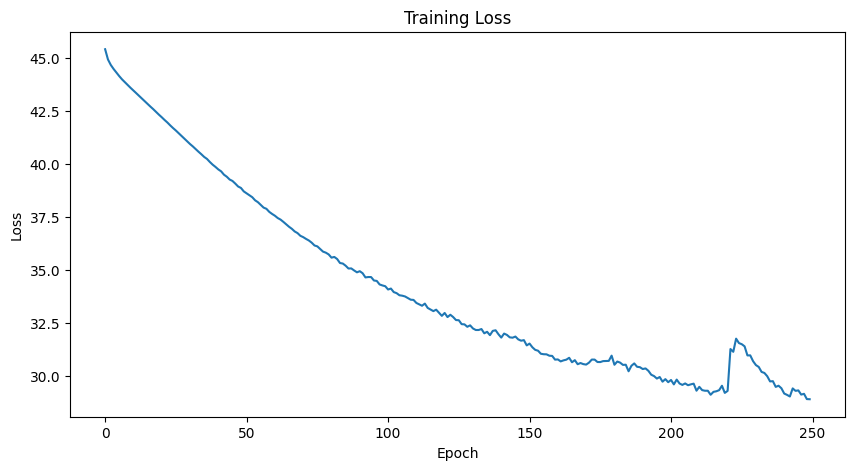

(np.float64(2.2244860999855587),
 np.float64(5.510736795051686),
 np.float64(6.4128660665018185),
 np.float64(5.510736798695863),
 np.float64(5.510737199559278),
 np.float64(3.6441765161043804e-09),
 np.float64(3.286250698710304),
 np.float64(2.2244860963413817),
 np.float64(0.9021292678059556))

In [6]:
flow_pid(m, x, y, n_flows = 3, n_epochs=250, batch_size=1000, lr=1e-3, verbose = True)

Gauss thin pid:  0.6237364881520628 0.0 1.3790799056061542 0.2948804412407333
1000


 20%|██        | 50/250 [00:02<00:13, 14.96it/s]

Epoch 50/250, Loss: 12.0029
Flow PID:  1.6591688381544705 1.114258907364274e-09 2.9957072492147203 0.660400241303793


 40%|███▉      | 99/250 [00:05<00:07, 20.08it/s]

Epoch 100/250, Loss: 8.2714
Flow PID:  1.7106151347542742 3.765467937455469e-09 3.054342529656381 0.6671021801040027


...

Epoch 150/250, Loss: 5.9046
Flow PID:  1.8176660436945529 3.009288818134337e-09 3.1772168713908027 0.7020835976636057


 80%|███████▉  | 199/250 [00:11<00:02, 20.55it/s]

Epoch 200/250, Loss: 4.0537
Flow PID:  1.8677093061758168 1.7014025743833372e-09 3.3707400821126825 0.7245293755913318


100%|██████████| 250/250 [00:14<00:00, 17.85it/s]

Epoch 250/250, Loss: 2.5889
Flow PID:  1.9425311489749433 3.163126649496917e-09 3.463264297649843 0.7220660562752839


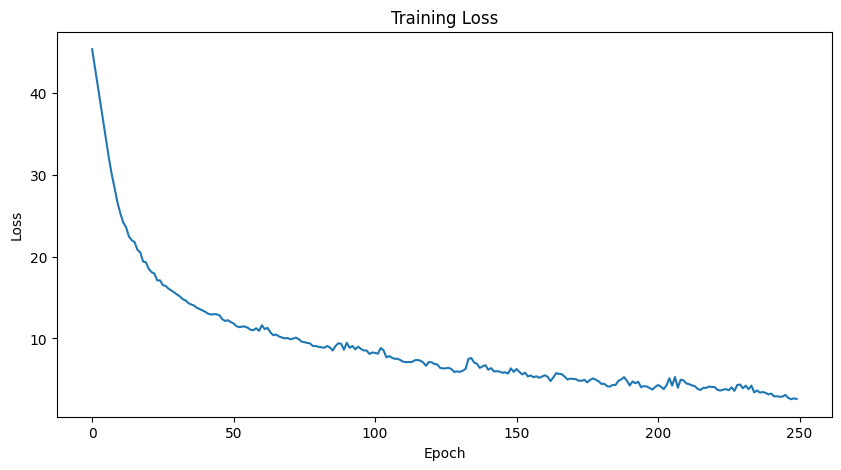

(np.float64(1.94253115213807),
 np.float64(5.405795446624786),
 np.float64(6.127861506063197),
 np.float64(5.405795449787913),
 np.float64(5.405795356187403),
 np.float64(3.163126649496917e-09),
 np.float64(3.463264297649843),
 np.float64(1.9425311489749433),
 np.float64(0.7220660562752839))

In [7]:
x_transformed = np.exp(x)
y_transformed = np.cbrt(y)
m_transformed = m**3

mxy_transformed = np.vstack((m_transformed.T, x_transformed.T, y_transformed.T))
cov_transformed = np.corrcoef(mxy_transformed)    # Shape: (dm+dx+dy, dm+dx+dy)
# print(cov_transformed)
ret = exact_gauss_tilde_pid(cov_transformed, dm, dx, dy)
print("Gauss thin pid: ", ret[7], ret[5], ret[6], ret[8])


flow_pid(m_transformed, x_transformed, y_transformed, n_flows = 3, n_epochs=250, batch_size=1000, lr=1e-3, verbose = True)
